In [3]:
!pip install pandas numpy matplotlib seaborn ipykernel

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)

   ---------- ----------------------------- 1/4 [contourpy]
   ---------- ----------------------------- 1/4 [contourpy]
   ---------- ----------------------------- 1/4 [contourpy]
   -------------------- ------------------- 2/4 [matplotlib]
   -------------------- ------------------- 2/4 [matplotlib]
   -------------------- ------------------- 2/4 [matplotlib]
   -------------------- ------------------- 2/4 [matplotlib]
   -------------------- ------------------- 2/4 [matplotli

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [6]:
df = pd.read_csv("../data/telco_churn.csv")
print("shape:",df.shape)
print("columns:",df.columns.tolist())

shape: (7043, 21)
columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [9]:
print(df['TotalCharges'].dtype)
print(df['TotalCharges'].head(10))

object
0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object


In [10]:
# Try to convert TotalCharges to numbers
# errors='coerce' means: "if you find something that's not a number, 
# replace it with NaN (empty)"
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Now check how many NaN values appeared
print("Missing values in TotalCharges:", df['TotalCharges'].isna().sum())

Missing values in TotalCharges: 11


In [11]:
# Check those specific rows where TotalCharges is missing
missing_rows = df[df['TotalCharges'].isna()]
print("Number of problem rows:", len(missing_rows))
print(missing_rows[['tenure', 'MonthlyCharges', 'TotalCharges']])

Number of problem rows: 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN


In [12]:
# These customers have tenure=0 so TotalCharges should logically be 0
df['TotalCharges'].fillna(0, inplace=True)

# Verify fix worked
print("Missing values remaining:", df['TotalCharges'].isna().sum())
print("Data type now:", df['TotalCharges'].dtype)

Missing values remaining: 0
Data type now: float64


C:\Users\Manvi\AppData\Local\Temp\ipykernel_25300\1161140962.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [13]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [14]:
# Convert Churn from Yes/No text to 1/0 numbers
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("Churn value counts:")
print(df['Churn'].value_counts())

print("\nChurn percentage:")
print(df['Churn'].value_counts(normalize=True) * 100)

Churn value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Churn percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


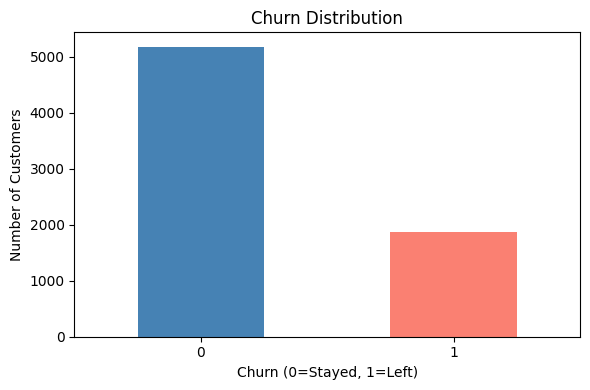

In [15]:
# Set figure size
plt.figure(figsize=(6, 4))

# Draw the bar chart
df['Churn'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])

# Labels
plt.title('Churn Distribution')
plt.xlabel('Churn (0=Stayed, 1=Left)')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

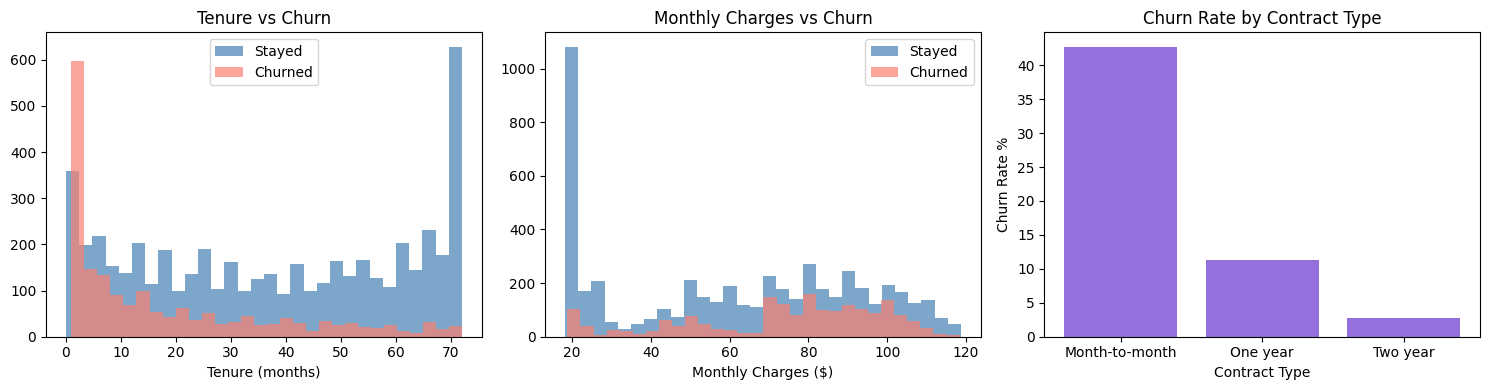

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: Tenure vs Churn
axes[0].hist(df[df['Churn']==0]['tenure'], bins=30, 
             alpha=0.7, color='steelblue', label='Stayed')
axes[0].hist(df[df['Churn']==1]['tenure'], bins=30, 
             alpha=0.7, color='salmon', label='Churned')
axes[0].set_title('Tenure vs Churn')
axes[0].set_xlabel('Tenure (months)')
axes[0].legend()

# Chart 2: MonthlyCharges vs Churn
axes[1].hist(df[df['Churn']==0]['MonthlyCharges'], bins=30,
             alpha=0.7, color='steelblue', label='Stayed')
axes[1].hist(df[df['Churn']==1]['MonthlyCharges'], bins=30,
             alpha=0.7, color='salmon', label='Churned')
axes[1].set_title('Monthly Charges vs Churn')
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].legend()

# Chart 3: Contract type vs Churn
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
axes[2].bar(contract_churn.index, contract_churn.values, color='mediumpurple')
axes[2].set_title('Churn Rate by Contract Type')
axes[2].set_xlabel('Contract Type')
axes[2].set_ylabel('Churn Rate %')

plt.tight_layout()
plt.show()

In [17]:
# Statistical summary of numeric columns
print("=== NUMERIC COLUMNS STATISTICS ===")
print(df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe())

=== NUMERIC COLUMNS STATISTICS ===
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2279.734304
std      24.559481       30.090047   2266.794470
min       0.000000       18.250000      0.000000
25%       9.000000       35.500000    398.550000
50%      29.000000       70.350000   1394.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [18]:
print("=== AVERAGE VALUES: CHURNED vs STAYED ===\n")

# Group by churn and get mean of numeric columns
comparison = df.groupby('Churn')[['tenure', 
                                   'MonthlyCharges', 
                                   'TotalCharges']].mean()

print(comparison)
print("\n--- What this tells us ---")
print(f"Churned customers avg tenure:    {comparison.loc[1,'tenure']:.1f} months")
print(f"Stayed customers avg tenure:     {comparison.loc[0,'tenure']:.1f} months")
print(f"\nChurned customers avg bill:      ${comparison.loc[1,'MonthlyCharges']:.2f}")
print(f"Stayed customers avg bill:       ${comparison.loc[0,'MonthlyCharges']:.2f}")

=== AVERAGE VALUES: CHURNED vs STAYED ===

          tenure  MonthlyCharges  TotalCharges
Churn                                         
0      37.569965       61.265124   2549.911442
1      17.979133       74.441332   1531.796094

--- What this tells us ---
Churned customers avg tenure:    18.0 months
Stayed customers avg tenure:     37.6 months

Churned customers avg bill:      $74.44
Stayed customers avg bill:       $61.27
